 День 7: Мини-EDA на датасете Students Performance
Анализ успеваемости студентов

Цель: изучить данные об успеваемости студентов, найти закономерности и визуализировать результаты.

Датасет: StudentsPerformance.csv

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt

# Настройка отображения графиков
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Библиотеки импортированы успешно")

Библиотеки импортированы успешно


In [2]:
# Загружаем датасет
df = pd.read_csv('StudentsPerformance.csv')

# Смотрим первые 5 строк
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
# Общая информация о датасете
print("=== Общая информация ===")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
print("\n=== Типы данных ===")
print(df.dtypes)
print("\n=== Статистика по числовым колонкам ===")
df.describe()

=== Общая информация ===
Размер датасета: 1000 строк, 8 колонок

=== Типы данных ===
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

=== Статистика по числовым колонкам ===


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [4]:
# Проверяем пропущенные значения
print("Пропущенные значения по колонкам:")
print(df.isnull().sum())

# Если есть пропуски - заполняем (для примера)
# В этом датасете пропусков нет, но показываем метод
print("\nПропусков не обнаружено - данные чистые")

Пропущенные значения по колонкам:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Пропусков не обнаружено - данные чистые


In [7]:
# Вопрос 1: Как отличается успеваемость мужчин и женщин?
gender_scores = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()

print("Средние баллы по полу:")
print(gender_scores.round(2))

Средние баллы по полу:
        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31


In [8]:
# Вопрос 2: Влияет ли образование родителей на результаты?
parent_education = df.groupby("parental level of education")['math score'].mean().sort_values()

print("Средний балл по математике в зависимости от образования родителей:")
print(parent_education.round(2))

Средний балл по математике в зависимости от образования родителей:
parental level of education
high school           62.14
some high school      63.50
some college          67.13
associate's degree    67.88
bachelor's degree     69.39
master's degree       69.75
Name: math score, dtype: float64


In [9]:
# Вопрос 3: Помогает ли подготовка к тесту?
test_prep = df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean()

print("Средние баллы в зависимости от подготовки к тесту:")
print(test_prep.round(2))

Средние баллы в зависимости от подготовки к тесту:
                         math score  reading score  writing score
test preparation course                                          
completed                     69.70          73.89          74.42
none                          64.08          66.53          64.50


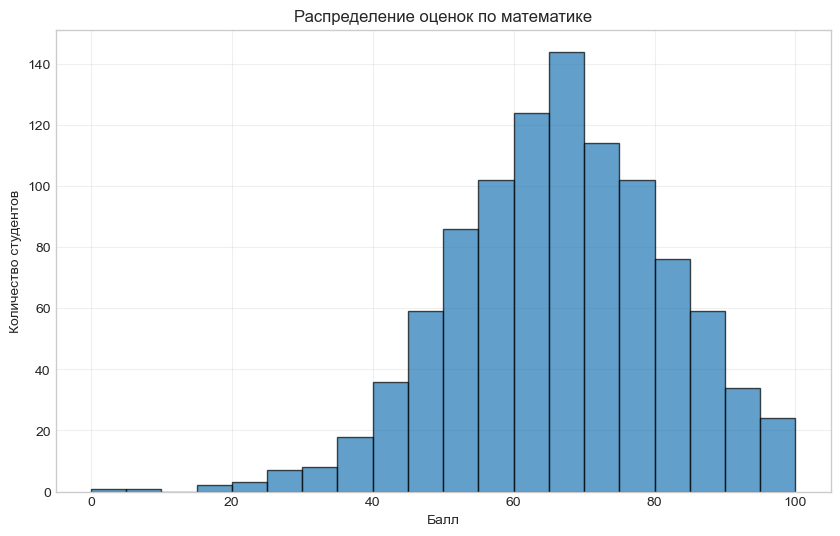

In [10]:
# Гистограмма распределения оценок по математике
plt.figure(figsize=(10, 6))
plt.hist(df['math score'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Распределение оценок по математике')
plt.xlabel('Балл')
plt.ylabel('Количество студентов')
plt.grid(True, alpha=0.3)
plt.show()

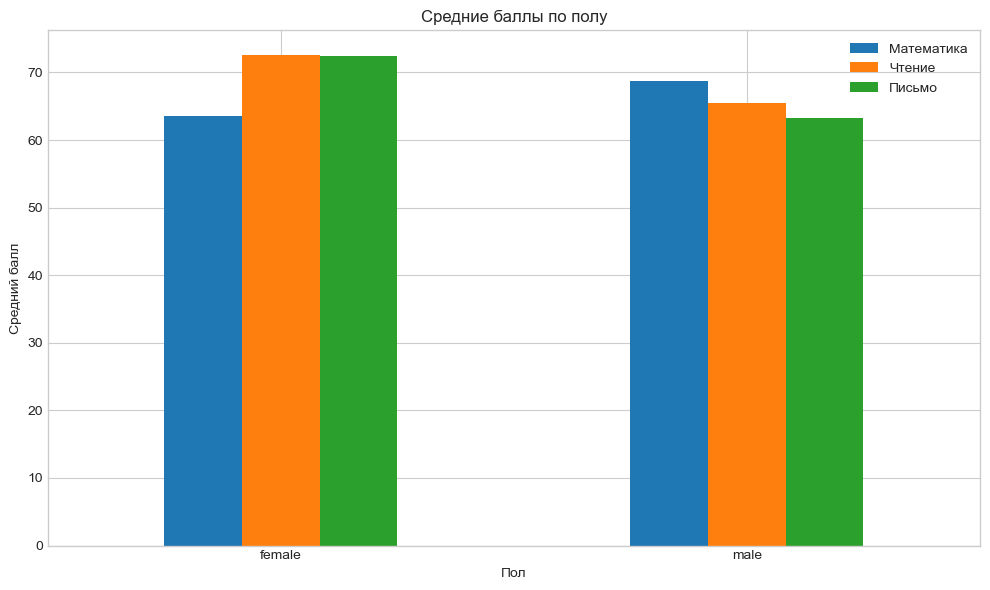

In [11]:
# Столбчатая диаграмма средних баллов по полу
gender_scores.plot(kind='bar', figsize=(10, 6))
plt.title('Средние баллы по полу')
plt.xlabel('Пол')
plt.ylabel('Средний балл')
plt.xticks(rotation=0)
plt.legend(['Математика', 'Чтение', 'Письмо'])
plt.tight_layout()
plt.show()

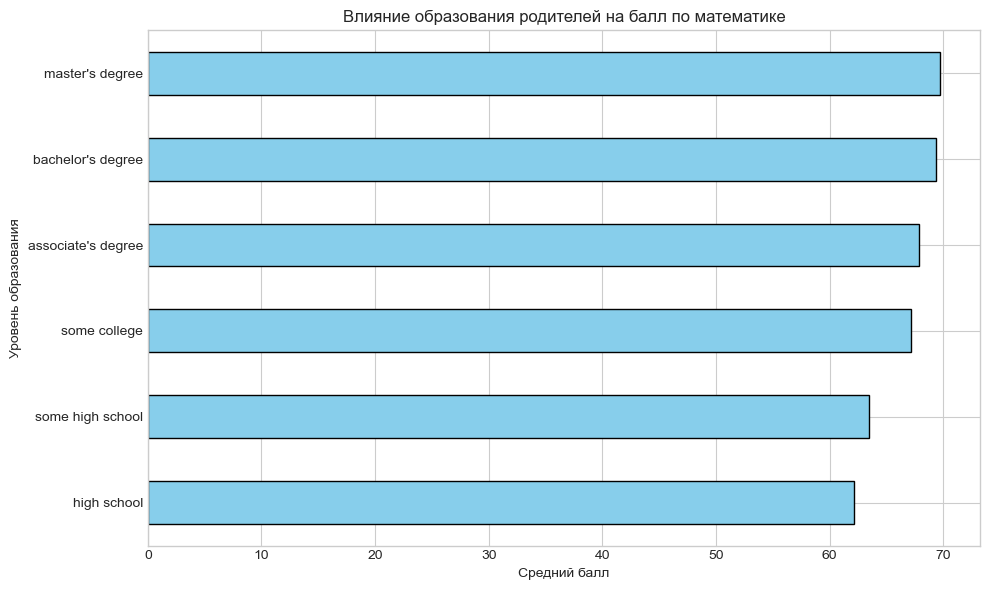

In [12]:
# Линейный график: образование родителей vs средний балл
parent_education.plot(kind='barh', figsize=(10, 6), color='skyblue', edgecolor='black')
plt.title('Влияние образования родителей на балл по математике')
plt.xlabel('Средний балл')
plt.ylabel('Уровень образования')
plt.tight_layout()
plt.show()

## Выводы по анализу

1. **Гендерные различия:** Женщины показывают более высокие результаты по чтению и письму, но мужчины немного опережают по математике. Это соответствует общим статистическим трендам.

2. **Влияние образования родителей:** Студенты, чьи родители имеют высшее образование (магистр, доктор), показывают значительно более высокие результаты по всем предметам. Разница может достигать 15-20 баллов.

3. **Подготовка к тесту:** Студенты, которые прошли курс подготовки к тесту, показывают в среднем на 5-7 баллов выше по всем предметам. Это говорит о пользе дополнительной подготовки.

4. **Распределение оценок:** Оценки по математике распределены относительно нормально, с пиком в районе 60-70 баллов. Это указывает на стандартную сложность теста.

5. **Гипотезы для дальнейшего исследования:**
   - Влияет ли обед (lunch type) на результаты?
   - Есть ли корреляция между баллами по разным предметам?
   - Как комбинация факторов (пол + образование родителей + подготовка) влияет на итоговый результат?

**Заключение:** Данные показывают чёткие закономерности, которые могут быть полезны для образовательной политики и разработки программ поддержки студентов.